In [2]:
from glob import glob
from cmcmultimodal.io import mat2nii
from pathlib import Path
import os

my_files = glob('../tests/testdata/Slice*.mat')
highres_files = []
lowres_files = []
for f in my_files:
    nii_highres, nii_lowres = mat2nii(f, nii_lowres_file=os.path.join(Path(f).parent,'lowres/',
                                      Path(f).name.replace('.mat','.nii.gz')), downsample=10)
    highres_files.append(nii_highres)
    lowres_files.append(nii_lowres)
    
highres_files

[PosixPath('../tests/testdata/Slice_007_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_006_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_004_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_014_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_005_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_010_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_009_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_003_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_013_EnR.nii.gz'),
 PosixPath('../tests/testdata/Slice_012_EnR.nii.gz')]

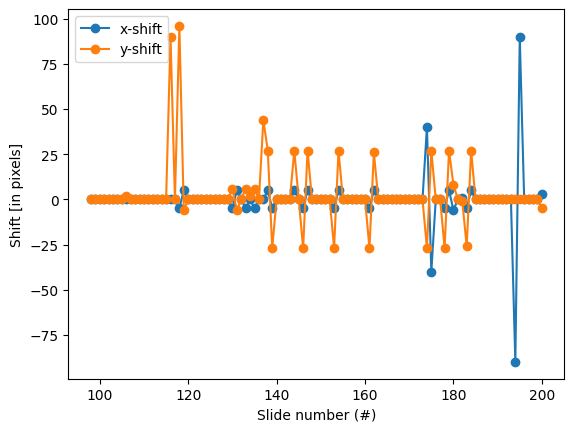

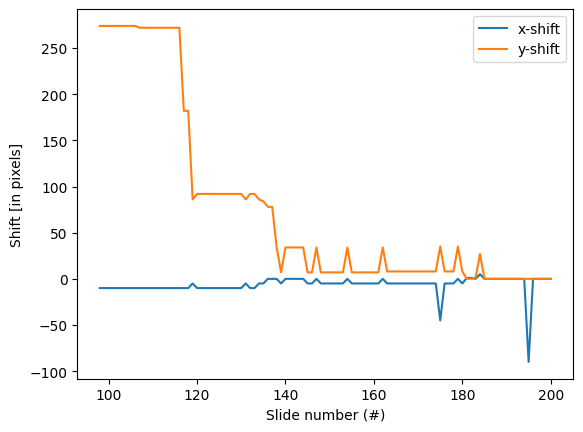

In [1]:
from cmcmultimodal.proc import psoct
from pathlib import Path
import numpy as np

datadir = '../tests/testdata'

my_data = psoct(Path(datadir), lowres=True, slide_range=(98,200))
slides, rel_shifts, abs_shifts = my_data.run_registration(bad_slides=[140,],plot_alignment = True)


In [2]:
output_path = '/Users/Vasilis/Downloads/PSOCT_test_output'
dti_ref = '../tests/benchmark/reoriented_FA.nii.gz'
# dti_ref = '../tests/benchmark/dti_FA.nii.gz'

psoct_in_dti_file = my_data.run_slide_deck_creation(slides, abs_shifts, orientation = 'coronal', output_path = output_path, dti_ref = dti_ref, downsample = 1)